In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../Augmente'))
import torch
from torch.utils.data import Dataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, RandomHorizontalFlip, RandomVerticalFlip, RandomRotation
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer

# Import autorskich augmentacji
from ScannerFocusLoss import RandomScannerFocusLoss
from StitchingEffect import RandomStitchingEffect
from MarkerEffect import RandomMarkerEffect
from InkEffect import RandomInkEffect

C:\Users\Mateusz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("=== DIAGNOSTYKA GPU ===")
if torch.cuda.is_available():
    print(f"Dostępne GPU: {torch.cuda.get_device_name(0)}")
    print(f"Liczba kart: {torch.cuda.device_count()}")
else:
    print("UWAGA: Brak dostępu do GPU! Trening pójdzie na procesorze (CPU).")
print("=======================\n")

=== DIAGNOSTYKA GPU ===
Dostępne GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Liczba kart: 1



In [3]:
BASE_DIR = Path(r"C:\Magisterka")
CSV_PATH = BASE_DIR / "luad_patches_with_splits_all_classes.csv"
df = pd.read_csv(CSV_PATH)

df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val = df[df["split"] == "val"].reset_index(drop=True)
df_test = df[df["split"] == "test"].reset_index(drop=True)

id2label = {0: "background", 1: "cribriform", 2: "micropapillary", 3: "solid", 4: "papillary", 5: "acinar", 6: "lepidic"}
label2id = {v: k for k, v in id2label.items()}
class_names = [id2label[i] for i in range(len(id2label))]

In [4]:
model_name = "microsoft/resnet-18"
processor = AutoImageProcessor.from_pretrained(model_name)
normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

if "shortest_edge" in processor.size:
    IMG_SIZE = processor.size["shortest_edge"]
else:
    IMG_SIZE = processor.size["height"]

# NASZ ZESTAW AUGMENTACJI MEDYCZNYCH
train_transforms = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    RandomScannerFocusLoss(p=0.15),
    RandomStitchingEffect(p=0.15),
    RandomMarkerEffect(p=0.15),
    RandomInkEffect(p=0.15),
    RandomHorizontalFlip(),
    RandomVerticalFlip(),
    RandomRotation(20),
    ToTensor(),
    normalize
])

eval_transforms = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    normalize
])

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [5]:
class PatchDataset(Dataset):
    def __init__(self, df_subset, transform):
        self.df = df_subset
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.transform(img)
        return {"pixel_values": pixel_values, "labels": int(row["dominant_label_id"])}

train_dataset = PatchDataset(df_train, train_transforms)
val_dataset = PatchDataset(df_val, eval_transforms)
test_dataset = PatchDataset(df_test, eval_transforms)

model = AutoModelForImageClassification.from_pretrained(
    model_name, num_labels=len(id2label), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
)

Loading weights: 100%|██████████| 122/122 [00:00<00:00, 685.91it/s, Materializing param=resnet.encoder.stages.3.layers.1.layer.1.normalization.weight]              
ResNetForImageClassification LOAD REPORT from: microsoft/resnet-18
Key                 | Status   |                                                                                          
--------------------+----------+------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 512]) vs model:torch.Size([7, 512])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([7])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [6]:
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0)
    }

In [7]:
training_args = TrainingArguments(
    output_dir=str(BASE_DIR / "augmented_results_resnet18"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=1e-4,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    dataloader_num_workers=0,
    remove_unused_columns=False
)

trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics)

print(f"Rozpoczynam trening modelu {model_name}...")
trainer.train()

print("\nEwaluacja na zbiorze testowym...")
predictions_output = trainer.predict(test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

print("\nRAPORT KLASYFIKACJI:")
print(classification_report(true_labels, predictions, target_names=class_names, zero_division=0))

Rozpoczynam trening modelu microsoft/resnet-18...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.501313,0.941912,0.745455,0.313404,0.304762,0.324786
2,0.883605,0.951590,0.690909,0.346522,0.330474,0.378358
3,0.662986,0.861250,0.718182,0.434796,0.482641,0.413919
4,0.523007,0.788566,0.709091,0.419174,0.477402,0.393926
5,0.435895,0.868345,0.700000,0.323486,0.342446,0.313492
6,0.432247,0.897461,0.681818,0.314628,0.342593,0.309524
7,0.373534,0.872751,0.700000,0.417594,0.473155,0.395757
8,0.330206,0.858816,0.745455,0.454104,0.507341,0.432692
9,0.283872,0.841643,0.727273,0.429765,0.481163,0.406899
10,0.302731,0.843761,0.709091,0.418142,0.470697,0.393926


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.57it/s]



Ewaluacja na zbiorze testowym...



RAPORT KLASYFIKACJI:
                precision    recall  f1-score   support

    background       0.83      0.95      0.88        73
    cribriform       0.50      0.20      0.29         5
micropapillary       0.00      0.00      0.00         2
         solid       0.75      0.69      0.72        13
     papillary       0.75      0.69      0.72        13
        acinar       0.00      0.00      0.00         1
       lepidic       0.00      0.00      0.00         3

      accuracy                           0.80       110
     macro avg       0.40      0.36      0.37       110
  weighted avg       0.75      0.80      0.77       110



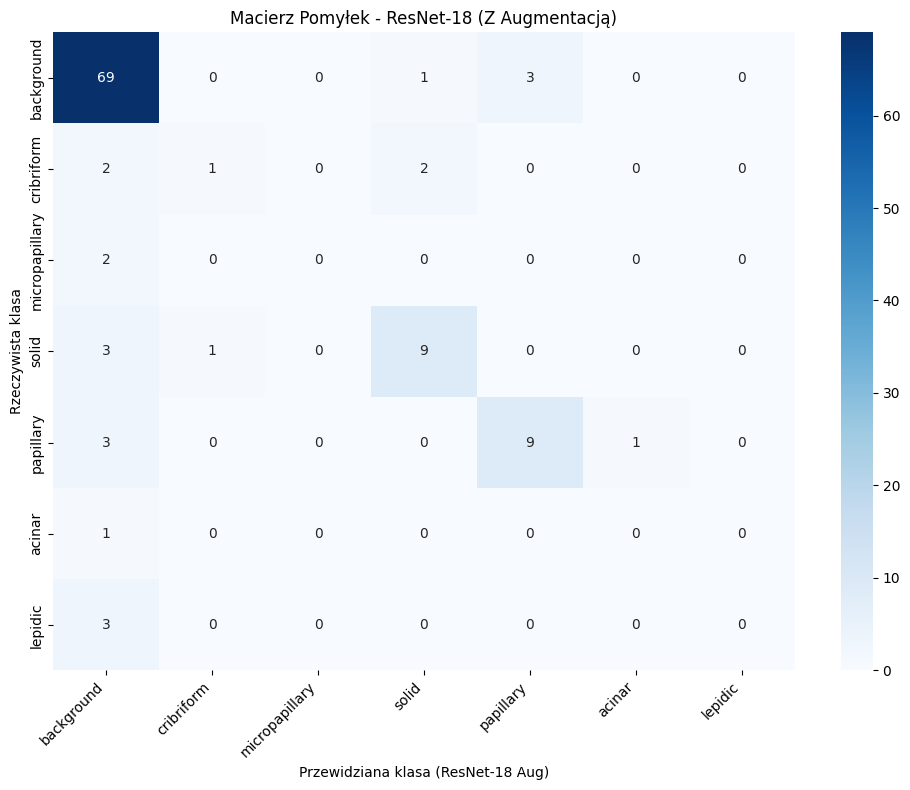

In [8]:
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Przewidziana klasa (ResNet-18 Aug)'); plt.ylabel('Rzeczywista klasa')
plt.title('Macierz Pomyłek - ResNet-18 (Z Augmentacją)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(BASE_DIR / "CM_Augmented_ResNet18.png", dpi=300)
plt.show()